# Импорт библиотек и настройка среды

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
pd.set_option("display.max_columns", 100)
pd.set_option('display.max_colwidth', None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Загрузка датасета и его краткая проверка

Загрузка датасета

In [19]:
data = pd.read_csv("../data/cs-training.csv")
data = data.drop(columns=["Unnamed: 0"], errors="ignore")

Улучшенное наименование столбцов

In [20]:
data = data.rename(columns={
    "SeriousDlqin2yrs": "target",
    "RevolvingUtilizationOfUnsecuredLines": "revoliving_utilization",
    "age": "age",
    "NumberOfTime30-59DaysPastDueNotWorse": "num_30_59_days_late",
    "DebtRatio": "debt_ratio",
    "MonthlyIncome": "monthly_income",
    "NumberOfOpenCreditLinesAndLoans": "num_open_credit_lines",
    "NumberOfTimes90DaysLate": "num_90_days_late",
    "NumberRealEstateLoansOrLines": "num_real_estate_loans",
    "NumberOfTime60-89DaysPastDueNotWorse": "num_60_89_days_late",
    "NumberOfDependents": "num_dependents"
})

Формирование описания признаков

In [21]:
data_dictionary = pd.DataFrame({
    "column": data.columns,
    "description": [
        "Был ли у человека за последние 2 года случай просрочки на 90 дней или более",
        "Общий баланс по кредитным картам и личным кредитным линиям, кроме недвижимости и долгов в рассрочку, например автокредитов, делённый на сумму кредитных лимитов",
        "Возраст заёмщика в годах",
        "Количество раз, когда заёмщик имел просрочку 30–59 дней, но не хуже, за последние 2 года",
        "Ежемесячные выплаты по долгам, алименты и расходы на проживание, делённые на ежемесячный валовый доход",
        "Ежемесячный доход",
        "Количество открытых кредитов, например автокредит или ипотека, и кредитных линий, например кредитных карт",
        "Количество раз, когда заёмщик имел просрочку 90 дней или более",
        "Количество ипотечных и других кредитов, связанных с недвижимостью, включая кредитные линии под залог жилья",
        "Количество раз, когда заёмщик имел просрочку 60–89 дней, но не хуже, за последние 2 года",
        "Количество иждивенцев в семье, не включая самого заёмщика: супруг/супруга, дети и т. д."
    ],
    "types": [
        "binary",
        "percent",
        "integer",
        "count",
        "percent",
        "float",
        "count",
        "count",
        "count",
        "count",
        "count"
    ],
    "role": [
        "target",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature"
    ]
})

Описание датасета

In [22]:
data_dictionary

,column,description,types,role
0,target,Был ли у человека за последние 2 года случай просрочки на 90 дней или более,binary,target
1,revoliving_utilization,"Общий баланс по кредитным картам и личным кредитным линиям, кроме недвижимости и долгов в рассрочку, например автокредитов, делённый на сумму кредитных лимитов",percent,feature
2,age,Возраст заёмщика в годах,integer,feature
3,num_30_59_days_late,"Количество раз, когда заёмщик имел просрочку 30–59 дней, но не хуже, за последние 2 года",count,feature
4,debt_ratio,"Ежемесячные выплаты по долгам, алименты и расходы на проживание, делённые на ежемесячный валовый доход",percent,feature
5,monthly_income,Ежемесячный доход,float,feature
6,num_open_credit_lines,"Количество открытых кредитов, например автокредит или ипотека, и кредитных линий, например кредитных карт",count,feature
7,num_90_days_late,"Количество раз, когда заёмщик имел просрочку 90 дней или более",count,feature
8,num_real_estate_loans,"Количество ипотечных и других кредитов, связанных с недвижимостью, включая кредитные линии под залог жилья",count,feature
9,num_60_89_days_late,"Количество раз, когда заёмщик имел просрочку 60–89 дней, но не хуже, за последние 2 года",count,feature


Размерность датасета

In [23]:
data.shape

(150000, 11)

Столбцы и типы данных датасета

In [24]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   target                  150000 non-null  int64  
 1   revoliving_utilization  150000 non-null  float64
 2   age                     150000 non-null  int64  
 3   num_30_59_days_late     150000 non-null  int64  
 4   debt_ratio              150000 non-null  float64
 5   monthly_income          120269 non-null  float64
 6   num_open_credit_lines   150000 non-null  int64  
 7   num_90_days_late        150000 non-null  int64  
 8   num_real_estate_loans   150000 non-null  int64  
 9   num_60_89_days_late     150000 non-null  int64  
 10  num_dependents          146076 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 12.6 MB


Краткий взгляд на данные

In [25]:
data.sample(3)

,target,revoliving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
112352,0,0.4256,40,1,0.3694,"5,416.0000",11,0,1,0,3.0000
65562,0,0.0188,57,0,0.2056,"11,997.0000",14,0,2,0,1.0000
107945,0,0.0000,47,0,0.3405,"3,500.0000",5,0,1,0,2.0000


# Общая проверка качества данных

Проверка наличия дубликатов

In [ ]:
duplicates_summary = (
    data.duplicated()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "duplicate_count", "mean": "duplicate_percent"})
)
duplicates_summary["duplicate_percent"] = duplicates_summary["duplicate_percent"] * 100

In [40]:
duplicates_summary

duplicate_count     609.0000
duplicate_percent     0.4060
dtype: float64

Первичная проверка наличия пропусков

In [51]:
missing_summary = (
    data.isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "missings_count", "mean": "missings_percent"})
)
missing_summary["missings_percent"] = missing_summary["missings_percent"] * 100

In [52]:
missing_summary

,missings_count,missings_percent
target,0.0000,0.0000
revoliving_utilization,0.0000,0.0000
age,0.0000,0.0000
num_30_59_days_late,0.0000,0.0000
debt_ratio,0.0000,0.0000
monthly_income,"29,731.0000",19.8207
num_open_credit_lines,0.0000,0.0000
num_90_days_late,0.0000,0.0000
num_real_estate_loans,0.0000,0.0000
num_60_89_days_late,0.0000,0.0000


# Распределение целевой переменной

Распределение целевой переменной

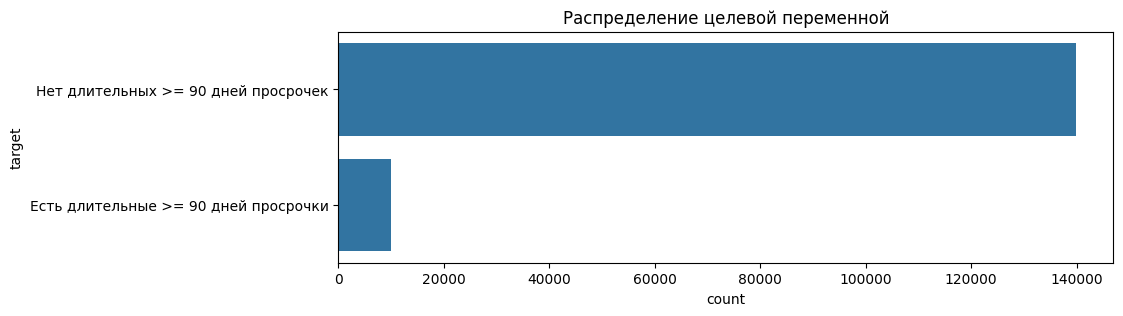

In [65]:
plt.figure(figsize=(10, 3))
sns.countplot(data, y="target")
plt.title("Распределение целевой переменной")
plt.yticks([0, 1], ["Нет длительных >= 90 дней просрочек", "Есть длительные >= 90 дней просрочки"], rotation=0)
plt.show()

In [68]:
target_class_stats = (
    data["target"]
    .value_counts()
    .rename_axis("target")
    .reset_index(name="count")
)
target_class_stats["ratio"] = target_class_stats["count"] / target_class_stats["count"].sum() * 100

In [69]:
target_class_stats

,target,count,ratio
0,0,139974,93.3160
1,1,10026,6.6840
